In [1]:
import pandas as pd
import seaborn as sns

In [3]:
stringency = pd.read_csv("../data/raw/OxCGRT_timeseries_StringencyIndex_v1.csv")
stringency = stringency[stringency['RegionName'] == 'Scotland'].T
stringency = stringency.iloc[7:,:].copy()
stringency.reset_index(inplace=True)
stringency.columns = ['date', 'stringency_index']
stringency['date'] = pd.to_datetime(stringency['date'], format='%d%b%Y')

containment = pd.read_csv("../data/raw/OxCGRT_timeseries_ContainmentHealthIndex_v1.csv")
containment = containment[containment['RegionName'] == 'Scotland'].T
containment = containment.iloc[7:,:].copy()
containment.reset_index(inplace=True)
containment.columns = ['date', 'containment_index']
containment['date'] = pd.to_datetime(containment['date'], format='%d%b%Y')

df = pd.merge(stringency, containment, on='date', how='inner')

In [4]:
df.head()

,date,stringency_index,containment_index
0,2020-01-01,0.0,0.0
1,2020-01-02,0.0,0.0
2,2020-01-03,0.0,0.0
3,2020-01-04,0.0,0.0
4,2020-01-05,0.0,0.0


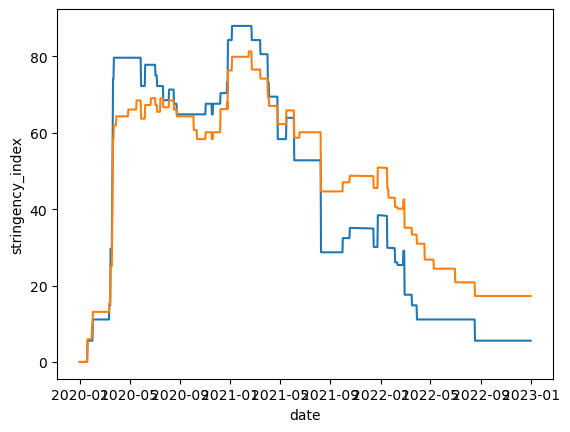

In [5]:
sns.lineplot(data=df, x='date',  y='stringency_index')
sns.lineplot(data=df, x='date',  y='containment_index');

In [10]:
df[['stringency_index', 'containment_index']].corr().iloc[0, 1]

np.float64(0.9633663899824596)

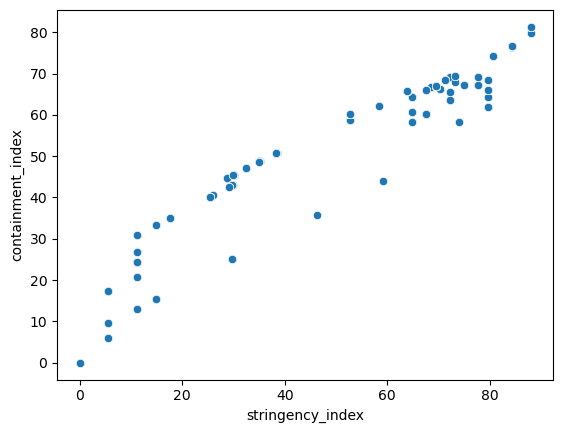

In [11]:
sns.scatterplot(data=df, x='stringency_index',  y='containment_index');

In [12]:
POLICY_PERIODS: pd.DataFrame = pd.DataFrame(
    {
        "period_code": [
            "E0",
            "L1",
            "P1",
            "P2",
            "P3",
            "T1",
            "F5",
            "L2",
            "SL",
            "L3",
            "L21",
            "L0",
            "NN",
            "OM",
            "FE",
            "PR",
        ],
        "period_label": [
            "Emergence",
            "First lockdown",
            "Route map phase 1",
            "Route map phase 2",
            "Route map phase 3",
            "Pre-tier tightening",
            "Five-tier framework",
            "Second lockdown",
            "Stay local — Level 3",
            "Level 3",
            "Level 2 / Level 1",
            "Level 0",
            "Near-normal",
            "Omicron wave",
            "Final easing",
            "Post-restriction",
        ],
        "start_date": pd.to_datetime(
            [
                "2020-03-01",
                "2020-03-24",
                "2020-05-29",
                "2020-06-19",
                "2020-07-10",
                "2020-10-02",
                "2020-11-02",
                "2021-01-05",
                "2021-04-02",
                "2021-04-26",
                "2021-05-17",
                "2021-07-19",
                "2021-08-09",
                "2021-11-29",
                "2022-01-24",
                "2022-04-18",
            ]
        ).normalize(),
        "end_date": pd.to_datetime(
            [
                "2020-03-23",
                "2020-05-28",
                "2020-06-18",
                "2020-07-09",
                "2020-10-01",
                "2020-11-01",
                "2021-01-04",
                "2021-04-01",
                "2021-04-25",
                "2021-05-16",
                "2021-07-18",
                "2021-08-08",
                "2021-11-28",
                "2022-01-23",
                "2022-04-17",
                "2023-05-05",
            ]
        ).normalize(),
    }
)


In [16]:
stringency_index = {
    code: (
        df.loc[
            (df['date'] >= start) & (df['date'] <= end), 'stringency_index'
            ].mean(),
        df.loc[
            (df['date'] >= start) & (df['date'] <= end), 'stringency_index'
            ].std()
    )         
    for code, start, end in zip(
        POLICY_PERIODS['period_code'],
        POLICY_PERIODS['start_date'],
        POLICY_PERIODS['end_date']
    )
}

stringency_index

{'E0': (np.float64(23.911739130434785), np.float64(20.369729469389778)),
 'L1': (np.float64(79.63000000000008), np.float64(0.0)),
 'P1': (np.float64(75.13238095238096), np.float64(2.8454207153985256)),
 'P2': (np.float64(76.45619047619047), np.float64(2.0838965333971755)),
 'P3': (np.float64(67.64571428571442), np.float64(2.977156922144104)),
 'T1': (np.float64(64.80999999999996), np.float64(1.444576078974261e-14)),
 'F5': (np.float64(70.88968750000001), np.float64(5.999394934769117)),
 'L2': (np.float64(85.53586206896566), np.float64(2.976495735672188)),
 'SL': (np.float64(69.90375000000003), np.float64(1.2533565803039897)),
 'L3': (np.float64(58.330000000000005), np.float64(7.280896430443988e-15)),
 'L21': (np.float64(56.13063492063501), np.float64(5.139857495519187)),
 'L0': (np.float64(52.77999999999999), np.float64(7.280896430443988e-15)),
 'NN': (np.float64(31.637857142857182), np.float64(2.9280388629612797)),
 'OM': (np.float64(34.83857142857142), np.float64(3.5185283228136104))